In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('dataset_task1.csv') #datset has been loaded

In [3]:
df.shape  #dataset has 7043 columns and 21 rows
df.columns #names of columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.head() #viewing first 5 rows in the dataset(Churn is the target column)
df.info() #total charges is object(need to convert it)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill NaN with median to avoid missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/tmp/ipython-input-595816302.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [5]:
if 'customerID' in df.columns:
  df=df.drop('customerID',axis=1)  #ran it twice by mistake

In [6]:
df.isnull().sum()  #checking null values
df.isna().sum() #checking NaN values
#no imputations required as there are no null or nan values

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [7]:
from sklearn.preprocessing import OneHotEncoder

# Keep Churn as 0 or 1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Select all categorical columns except 'Churn'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Churn']

# One-hot encode these columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Now df has Churn as 0/1 and all other categorical columns one-hot encoded
print(df.head())


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [8]:
onehot_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
               "OnlineBackup", "DeviceProtection", "TechSupport",
               "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# Keep only columns that exist
onehot_cols = [col for col in onehot_cols if col in df.columns]

# Apply one-hot encoding
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)


In [9]:
df.head() #Viewing new columns

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Churn
0    5174
1    1869
Name: count, dtype: int64


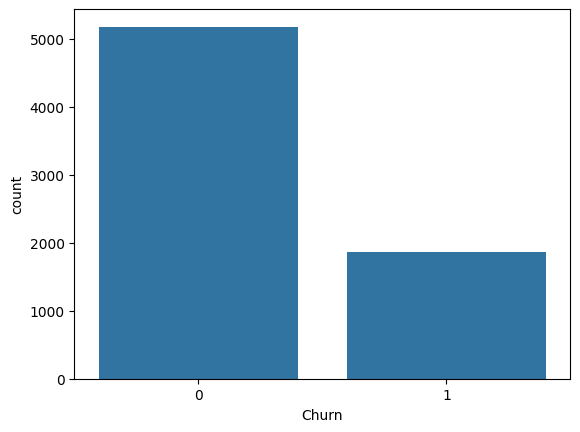

In [10]:
print(df["Churn"].value_counts())
sns.countplot(x="Churn",data=df)
plt.show()
#The dataset clearly has class imbalance. I will use SMOTE to handle it.

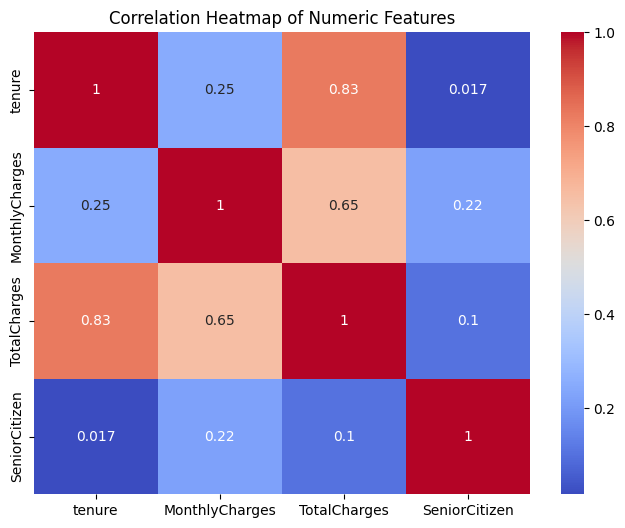

In [ ]:
#Chose numerical features to analyse correlation
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
# Splitting target and other columns

In [ ]:
from sklearn.model_selection import train_test_split
X_train_res,X_test,y_train_res,y_test=train_test_split(X,y,test_size=0.2)
#splitting dataset: 20% testing ,80% training


In [ ]:
from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)
#SMOTE will help in adding synthetic data of minority class


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

# Scaling data before applying ML algorithms
X_train_res[numeric_cols] = scaler.fit_transform(X_train_res[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


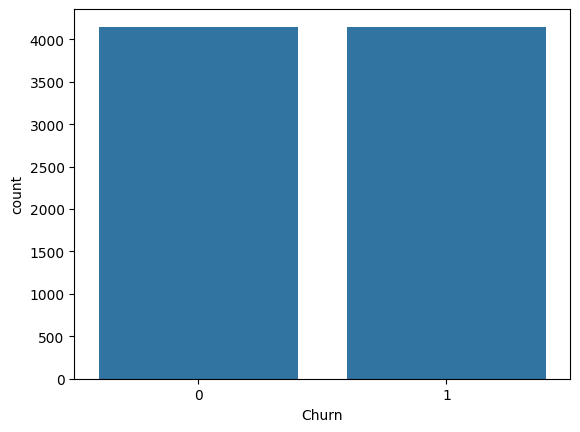

In [ ]:
#final review of dataset

X_train_res
y_train_res
sns.countplot(x=y_train_res,data=df)
plt.show()

In [ ]:
# Using RandomForest Algorithm for bagging

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix
rf=RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200, 300],          # number of trees
    'max_depth': [None,10, 20,30],         # depth of each tree
    'min_samples_split': [2, 5, 10],         # minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],           # minimum samples at a leaf node
    'max_features': ['auto', 'sqrt']         # number of features considered for split
}
#grid search calculates each permutationa and combination and gives us the best parameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=0, scoring='accuracy')

grid_search.fit(X_train_res, y_train_res)

grid_search.best_params_ #gives us the best parameters

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 648.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py",

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [ ]:
#In the previous cell, I used grid search cv for Hyperparameter tuning and finding the best attributes for our classifier
rf_best = RandomForestClassifier(
   n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf_best.fit(X_train_res, y_train_res)
y_pred = rf_best.predict(X_test)



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


print(accuracy)
print(f1)
print(cm)
#accuracy is decent, f1 is moderate
#The model predicts non-churn better than churn.


0.7764371894960965
0.5783132530120482
[[878 148]
 [167 216]]


In [ ]:
#Now lets try LDA(Linear Discriminant Analysis)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis()
lda.fit(X_train_res,y_train_res)
y_pred_lda=lda.predict(X_test)


In [ ]:
print(accuracy_score(y_test, y_pred_lda))
print(f1_score(y_test, y_pred_lda))
print(confusion_matrix(y_test, y_pred_lda))
#accuracy is slightly better than Random Forest.

0.7842441447835344
0.6190476190476191
[[858 168]
 [136 247]]


In [ ]:
#Now lets try QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)  #had to add reg_param because f1 was showing value 0, adds a small value to the diagonal of the covariance matrix
qda.fit(X_train_res,y_train_res)
y_pred_qda=qda.predict(X_test)


In [ ]:
print(accuracy_score(y_test, y_pred_qda))
print(f1_score(y_test, y_pred_qda))
print(confusion_matrix(y_test, y_pred_qda))
#accuracy fell off and f1 increased slightly

0.7324343506032647
0.6156982670744139
[[730 296]
 [ 81 302]]


In [ ]:
pip install xgboost

In [ ]:
#Now using XGBoost Algorithm
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb.fit(X_train_res,y_train_res)
xgb_pred=xgb.predict(X_test)

In [ ]:
print(accuracy_score(y_test, xgb_pred))
print(f1_score(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
#good accuracy as well as f1

0.7877927608232789
0.607095926412615
[[879 147]
 [152 231]]


In [ ]:
pip install scipy

In [ ]:
#Logistic Regression from scratch:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=2000):
        self.lr = lr                  #learning rate
        self.epochs = epochs
        self.W = None               #Weight vector
        self.b = None               #bias

    def sigmoid(self, z):         #sigmoid function
        return 1 / (1 + np.exp(-z))

    def loss(self, y, y_hat):
        eps = 1e-9  # avoids log(0)
        return -np.mean(y * np.log(y_hat + eps) +
                        (1 - y) * np.log(1 - y_hat + eps))         #L=−n1​∑[ylog(y^​)+(1−y)log(1−y^​)]

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.W = np.zeros(n_features)
        self.b = 0

        for epoch in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_hat = self.sigmoid(z)

            # gradients
            dW = (1 / n_samples) * np.dot(X.T, (y_hat - y))
            db = (1 / n_samples) * np.sum(y_hat - y)

            # update
            self.W -= self.lr * dW
            self.b -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Loss: {self.loss(y, y_hat):.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.W) + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [ ]:
X_train_res = X_train_res.astype(np.float64)   #Converting to float values
y_train_res = y_train_res.astype(np.float64)

X_test = X_test.astype(np.float64)
y_test = y_test.astype(np.float64)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegressionScratch(
    lr=0.1,
    epochs=2000
)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Epoch 0 | Loss: 0.6931
Epoch 100 | Loss: 0.4856
Epoch 200 | Loss: 0.4690
Epoch 300 | Loss: 0.4591
Epoch 400 | Loss: 0.4520
Epoch 500 | Loss: 0.4467
Epoch 600 | Loss: 0.4425
Epoch 700 | Loss: 0.4391
Epoch 800 | Loss: 0.4363
Epoch 900 | Loss: 0.4339
Epoch 1000 | Loss: 0.4318
Epoch 1100 | Loss: 0.4300
Epoch 1200 | Loss: 0.4284
Epoch 1300 | Loss: 0.4270
Epoch 1400 | Loss: 0.4257
Epoch 1500 | Loss: 0.4245
Epoch 1600 | Loss: 0.4234
Epoch 1700 | Loss: 0.4224
Epoch 1800 | Loss: 0.4214
Epoch 1900 | Loss: 0.4205
Test Accuracy: 0.7650816181689141

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.80      0.83      1026
         1.0       0.56      0.68      0.61       383

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [ ]:
#Lets try LogistiCRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

logreg = LogisticRegression()
param_distributions = {
    'C': uniform(0.01, 10),        # Regularization strength
    'penalty': ['l1', 'l2'],       # Regularization type
    'class_weight': [None, 'balanced']
}
random_search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_distributions,
    n_iter=50,            # number of random parameter settings to try
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42
)
random_search.fit(X_train_res, y_train_res)
y_pred_lr = random_search.predict(X_test)


Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
print(accuracy)
print(f1)
print(cm)


0.7828246983676366
0.6066838046272494
[[867 159]
 [147 236]]


Sklearn logistic regression has higher accuracy mainly because it uses regularization.

In [ ]:
X_train_res.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,-0.527001,1.077767,-0.286172,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.842399,1.721412,2.847546,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,-1.108959,-1.470723,-0.923866,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,-0.984254,0.018360,-0.816684,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.842399,0.169704,1.461698,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [ ]:
y_train_res.head()

,Churn
0,1.0
1,0.0
2,0.0
3,1.0
4,0.0


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')   # 0/1 churn output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8447 - loss: 0.3392 - val_accuracy: 0.8892 - val_loss: 0.2421
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8522 - loss: 0.3389 - val_accuracy: 0.9018 - val_loss: 0.2103
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8464 - loss: 0.3353 - val_accuracy: 0.9241 - val_loss: 0.1556
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8515 - loss: 0.3333 - val_accuracy: 0.9295 - val_loss: 0.1844
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3213 - val_accuracy: 0.9054 - val_loss: 0.1968
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8468 - loss: 0.3375 - val_accuracy: 0.9102 - val_loss: 0.1931
Epoch 7/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8535 - loss: 0.3240 - val_accuracy: 0.9090 - val_loss: 0.1954
Epoch 8/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8555 - loss: 0.3301 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc, test_loss)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7714 - loss: 0.4874
0.779985785484314 0.48782965540885925


Unsupervised Learning

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [12]:
X = X.astype(int)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducing to 2 dimensions
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

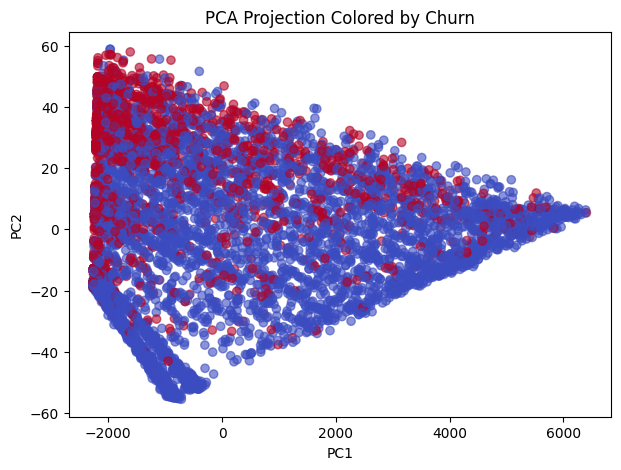

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Colored by Churn")
plt.show()
#As the churn colours are mixed together, clusters are not clearly visible

In [16]:
#pca with 3 components
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

# Reduce to 3 dimensions
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X)

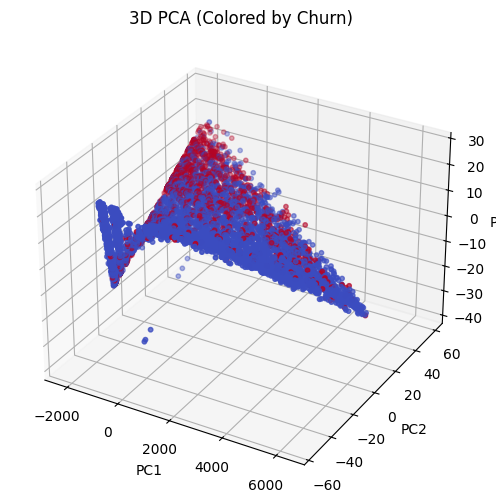

In [17]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=y,          # churn labels
    cmap='coolwarm',
    s=10
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA (Colored by Churn)")

plt.show()
#This clearly shows that clusters will not be very seperable as the points overlap


In [29]:
import numpy as np

class KMeansScratch:
    def __init__(self, n_clusters=3, max_iters=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol   # if centroid shift is smaller than tol, stop the algorithm

    def fit(self, X_scaled):
        X_scaled = np.asarray(X_scaled, dtype=np.float64)
        n_samples, n_features = X_scaled.shape

        # Initialize centroids randomly from data points
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X_scaled[random_idx]

        for _ in range(self.max_iters):
            # Compute Euclidean distances (vectorized)
            distances = np.linalg.norm(X_scaled[:, np.newaxis] - self.centroids, axis=2)

            # Assign each point to the nearest centroid
            self.labels_ = np.argmin(distances, axis=1)

            # Update centroids
            new_centroids = np.array([
                X_scaled[self.labels_ == k].mean(axis=0) if np.any(self.labels_ == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # Check convergence
            shift = np.linalg.norm(self.centroids - new_centroids)
            self.centroids = new_centroids

            if shift < self.tol:
                break

    def predict(self, X_scaled):
        X_scaled = np.asarray(X_scaled, dtype=np.float64)
        distances = np.linalg.norm(X_scaled[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [31]:
kmeans = KMeansScratch(n_clusters=2)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.centroids

print("Cluster labels (first 10):", labels[:30])
print("Centroids:\n", centroids)

Cluster labels (first 10): [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1]
Centroids:
 [[-3.47465700e-01 -7.42725786e-02 -1.45174418e+00 -7.12468227e-01
   1.14573827e-02  1.16967688e-03  2.65838769e-01  3.27438310e-01
  -3.27438310e-01 -4.00366162e-01 -8.85659760e-01  1.90140322e+00
   1.90140322e+00 -6.33932977e-01  1.90140322e+00 -7.25562723e-01
   1.90140322e+00 -7.23967524e-01  1.90140322e+00 -6.39438642e-01
   1.90140322e+00 -7.90131709e-01  1.90140322e+00 -7.96070144e-01
   7.22608185e-02  4.15034917e-01 -6.10375276e-01  1.95793065e-03
  -5.41741428e-01  6.11036331e-01]
 [ 9.61088742e-02  2.05437656e-02  4.01551861e-01  1.97068428e-01
  -3.16910747e-03 -3.23532158e-04 -7.35308975e-02 -9.05693059e-02
   9.05693059e-02  1.10741121e-01  2.44973136e-01 -5.25927373e-01
  -5.25927373e-01  1.75345609e-01 -5.25927373e-01  2.00690360e-01
  -5.25927373e-01  2.00249129e-01 -5.25927373e-01  1.76868473e-01
  -5.25927373e-01  2.18550116e-01 -5.25927373e-01  2.20192684e-01
  -1.9

In [32]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} points")


Cluster 0: 1526 points
Cluster 1: 5517 points


In [34]:
for cluster_id in np.unique(labels):
    idx = labels == cluster_id
    churn_rate = y[idx].mean()
    print(f"Cluster {cluster_id}: churn rate = {churn_rate:.2f}")
#So Cluster 0 is low risk customers while cluster 1 is high risk

Cluster 0: churn rate = 0.07
Cluster 1: churn rate = 0.32


In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette Score:", silhouette_score(X,labels)) #range from -1 to 1, clusters are not very well seperated
print("Davies-Bouldin Index:", davies_bouldin_score(X,labels)) #range from 0 to infinity,clusters are compact and separated
print("Calinski-Harabasz Score:", calinski_harabasz_score(X,labels)) #range from 0 to infinty, clusters are fairly compact and separated
#Clusters are well defined
#This means customers in particular clusters are well seprated and tells us that this dataset is quite good for binary classification

Silhouette Score: -0.02940915474595776
Davies-Bouldin Index: 1.2140900402763426
Calinski-Harabasz Score: 1150.6566594564124


In [23]:
#K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [24]:
#elbow method:
sse = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

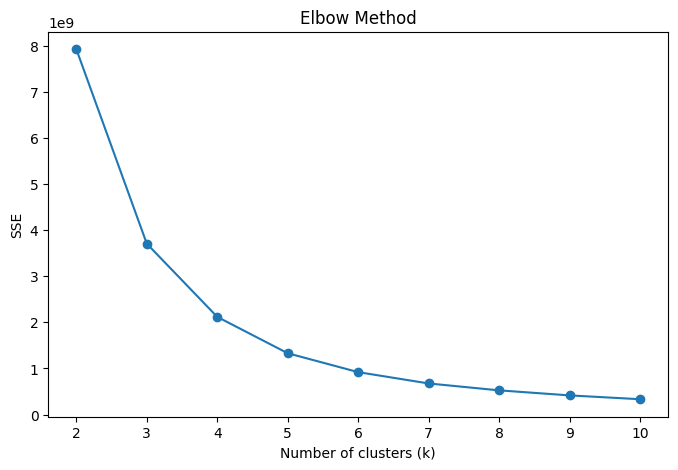

In [25]:
#plotting elbow method:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()
#k=3 seems optimal

In [26]:
best_k = 0
best_score = -1
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k
        print(f"Best k so far: {best_k} with silhouette score {best_score}")



Best k so far: 2 with silhouette score 0.33493900635754426


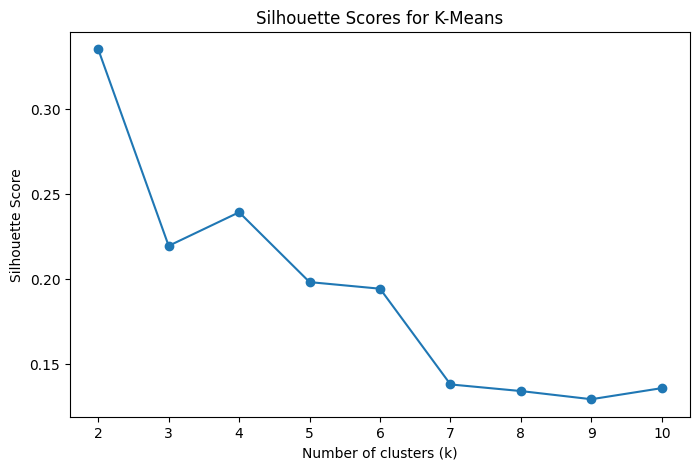

Optimal K (max silhouette score): 2


In [27]:
#plotting silhouette scores
plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means')
plt.show()

print(f"Optimal K (max silhouette score): {best_k}")

#Choosing k=2

In [28]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

k_best = 2
kmeans = KMeans(n_clusters=k_best, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, k_labels)) #range from -1 to 1, clusters are well seperated
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, k_labels)) #range from 0 to infinity,clusters are compact and separated
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, k_labels)) #range from 0 to infinty, clusters are fairly compact and separated
#Clusters are well defined
#This means customers in particular clusters are well seprated and tells us that this dataset is quite good for binary classification

Silhouette Score: 0.33493900635754426
Davies-Bouldin Index: 1.092962133986847
Calinski-Harabasz Score: 3162.3005429272234


Scikit K-Means uses initialization by default so the centroids chosen are not random. While in our implementation we chose centroids randomly